# Базовый блок. Архитектура автокодировщика (Autoencoder). ДЗ Lite

## Задание

Добейтесь на автокодировщике с 2-мерным скрытым пространством на 3-х цифрах: 0, 1 и 3 — ошибки MSE < 0.034 на скорости обучения 0.001 на 10-й эпохе.

## Импорт библиотек

In [1]:
# Работа с операционной системой
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

# Операции с путями
import glob

# Работа с массивами данных
import numpy as np

# Слои
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input, Conv2DTranspose, concatenate, Activation, MaxPooling2D, Conv2D, BatchNormalization, Concatenate

# Модель
from tensorflow.keras import Model

# Загрузка модели
from tensorflow.keras.models import load_model

# Датасет
from tensorflow.keras.datasets import mnist

# Оптимизатор для обучения модели
from tensorflow.keras.optimizers import Adam

# Коллбэки для выдачи информации в процессе обучения
from tensorflow.keras.callbacks import LambdaCallback

%matplotlib inline

## Утилиты

Функция-коллбэк. Отрисовывает объекты в скрытом пространстве

In [2]:
def ae_on_epoch_end(epoch, logs):
    print('______________________________________')
    print(f'*** ЭПОХА: {epoch+1}, loss: {logs["loss"]} ***')
    print('______________________________________')

    # Получение картинки латентного пространства в конце эпохи и запись в файл
    plt.figure(dpi=100)

    # Предсказание энкодера на тренировочной выборке
    predict = encoder.predict(X_train)

    # Создание рисунка: множество точек на плоскости 3-х цветов (3-х классов)
    scatter = plt.scatter(predict[:,0], predict[:,1], c=y_train, alpha=0.6, s=5)

    # Создание легенды
    legend2 = plt.legend(*scatter.legend_elements(), loc='upper right', title='Классы')

    # Сохранение картинки с названием, которого еще нет
    paths = glob.glob('*.jpg')
    plt.savefig(f'image_{str(len(paths))}.jpg')

    # Отображение
    plt.show()


ae_callback = LambdaCallback(on_epoch_end=ae_on_epoch_end)

Удаление изображений. Применять при обучении новой модели, чтобы не было путаницы в картинках.

In [3]:
def clean():
    # Получение названий всех картинок
    paths = glob.glob('*.jpg')
    # Удаление всех картинок по полученным путям
    for p in paths:
        os.remove(p)

# Удаление всех картинок
clean()

## Загрузка данных

In [4]:
# Загрузка датасета
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Нормировка
X_train = X_train.astype('float32')/255.
X_train = X_train.reshape(-1, 28, 28, 1)

In [6]:
# Выбор визуализируемых классов (цифр) и формирование подвыборок для них по маске
numbers = [0, 1, 3]
mask = np.array([(i in numbers) for i in y_train])
X_train = X_train[mask]
y_train = y_train[mask]

## Создание модели и обучение

### Решение

In [7]:
# Энкодер: переводит изображение 28x28 в латентное пространство размерности 2
encoder_input = Input(shape=(28, 28, 1))

x = Conv2D(32, (3, 3), padding='same', activation='relu')(encoder_input)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)        # 14 x 14 x 32

x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)        # 7 x 7 x 64

x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)

x = Flatten()(x)
x = Dense(64, activation='relu')(x)
latent = Dense(2, activation='linear', name='latent_space')(x)

encoder = Model(encoder_input, latent, name='encoder')
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 495,170 (1.89 MB)

 Trainable params: 494,722 (1.89 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# Декодер: восстанавливает изображение 28x28 из латентного представления размерности 2
decoder_input = Input(shape=(2,))

x = Dense(64, activation='relu')(decoder_input)
x = Dense(7 * 7 * 128, activation='relu')(x)
x = Reshape((7, 7, 128))(x)

x = Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')(x)  # 14 x 14
x = BatchNormalization()(x)

x = Conv2DTranspose(32, (3, 3), strides=2, padding='same', activation='relu')(x)  # 28 x 28
x = BatchNormalization()(x)

decoder_output = Conv2D(1, (3, 3), padding='same', activation='sigmoid')(x)

decoder = Model(decoder_input, decoder_output, name='decoder')
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6272)           │       407,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,801 (1.91 MB)

 Trainable params: 500,609 (1.91 MB)

 Non-trainable params: 192 (768.00 B)

In [9]:
# Сборка автокодировщика
autoencoder = Model(encoder_input, decoder(encoder(encoder_input)), name='autoencoder')

# Компиляция: оптимизатор Adam с learning_rate = 0.001, функция потерь MSE
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │       495,170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │       500,801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 995,971 (3.80 MB)

 Trainable params: 995,331 (3.80 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - loss: 0.0989______________________________________
*** ЭПОХА: 1, loss: 0.06719208508729935 ***
______________________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step


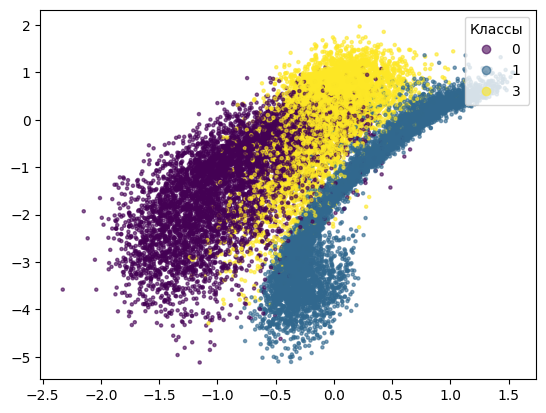

147/147 ━━━━━━━━━━━━━━━━━━━━ 102s 650ms/step - loss: 0.0672
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - loss: 0.0384______________________________________
*** ЭПОХА: 2, loss: 0.03567997366189957 ***
______________________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step


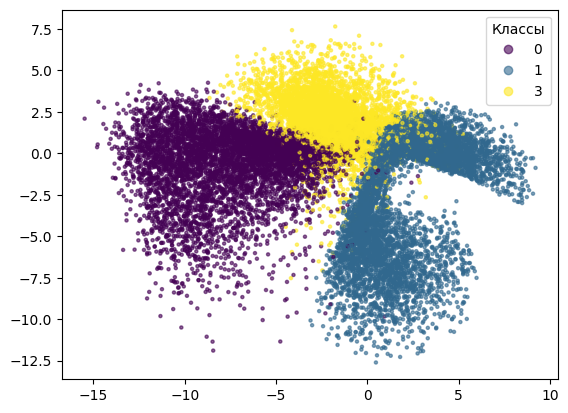

147/147 ━━━━━━━━━━━━━━━━━━━━ 148s 694ms/step - loss: 0.0357
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - loss: 0.0315______________________________________
*** ЭПОХА: 3, loss: 0.031038763001561165 ***
______________________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step


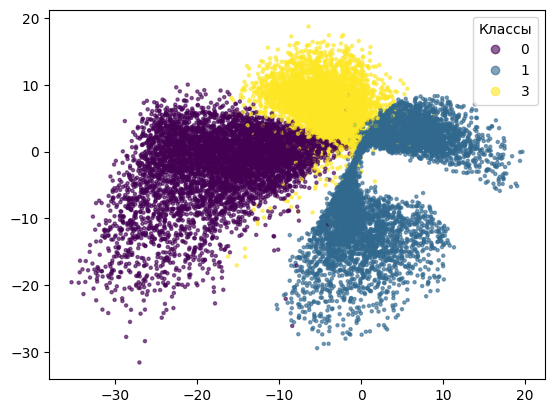

147/147 ━━━━━━━━━━━━━━━━━━━━ 136s 653ms/step - loss: 0.0310
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - loss: 0.0300______________________________________
*** ЭПОХА: 4, loss: 0.029685018584132195 ***
______________________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step


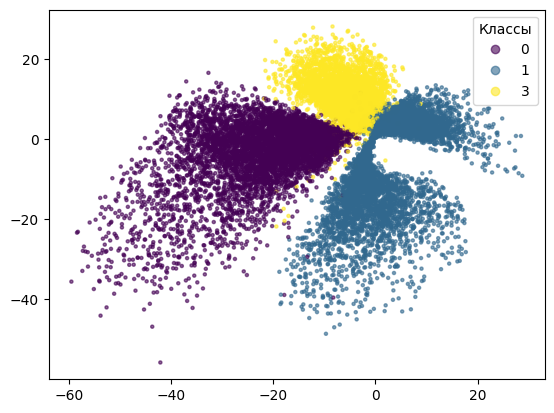

147/147 ━━━━━━━━━━━━━━━━━━━━ 96s 653ms/step - loss: 0.0297
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - loss: 0.0294______________________________________
*** ЭПОХА: 5, loss: 0.029250435531139374 ***
______________________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step


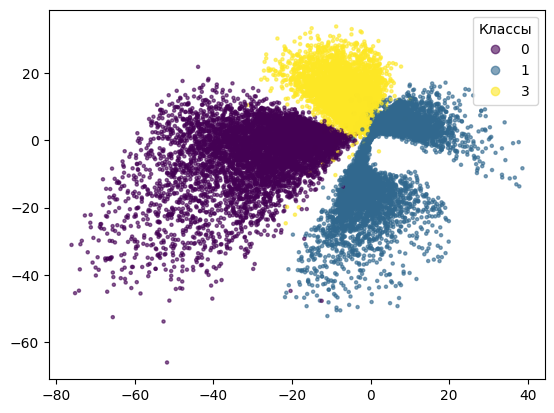

147/147 ━━━━━━━━━━━━━━━━━━━━ 95s 645ms/step - loss: 0.0293
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - loss: 0.0287______________________________________
*** ЭПОХА: 6, loss: 0.028668072074651718 ***
______________________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step


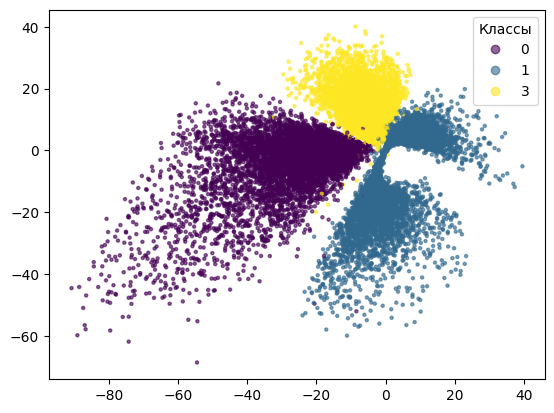

147/147 ━━━━━━━━━━━━━━━━━━━━ 146s 673ms/step - loss: 0.0287
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - loss: 0.0283______________________________________
*** ЭПОХА: 7, loss: 0.028513727709650993 ***
______________________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step


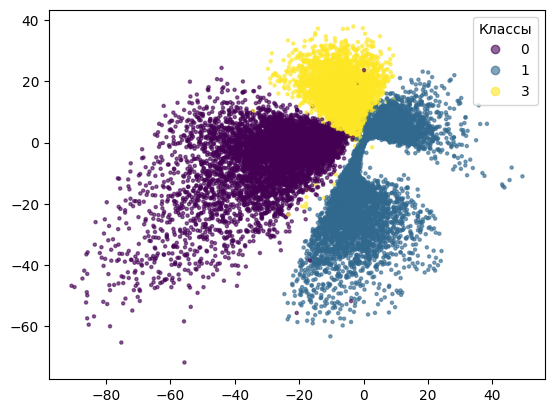

147/147 ━━━━━━━━━━━━━━━━━━━━ 139s 652ms/step - loss: 0.0285
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - loss: 0.0283______________________________________
*** ЭПОХА: 8, loss: 0.028150368481874466 ***
______________________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step


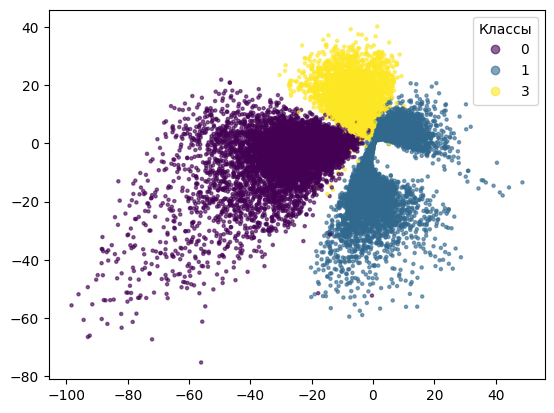

147/147 ━━━━━━━━━━━━━━━━━━━━ 94s 637ms/step - loss: 0.0282
Epoch 9/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - loss: 0.0280______________________________________
*** ЭПОХА: 9, loss: 0.02800343744456768 ***
______________________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step


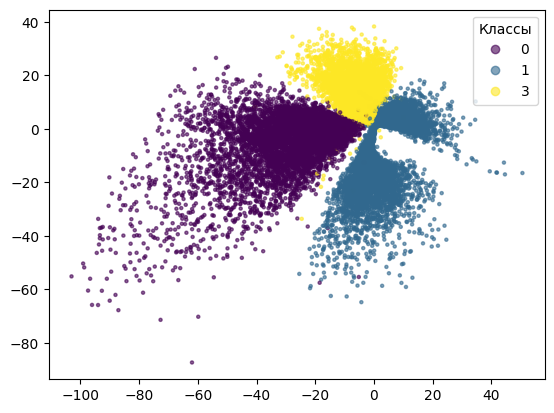

147/147 ━━━━━━━━━━━━━━━━━━━━ 93s 633ms/step - loss: 0.0280
Epoch 10/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - loss: 0.0280______________________________________
*** ЭПОХА: 10, loss: 0.027944430708885193 ***
______________________________________
588/588 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step


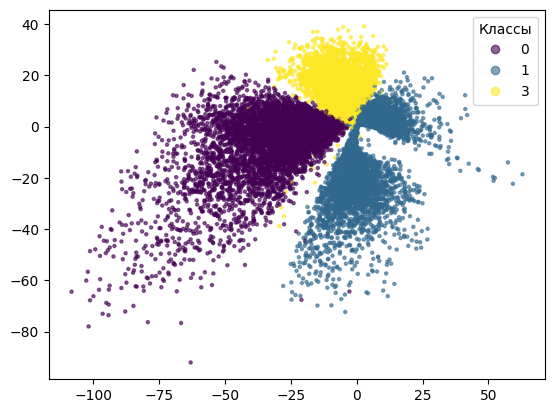

147/147 ━━━━━━━━━━━━━━━━━━━━ 94s 638ms/step - loss: 0.0279


In [10]:
# Очищаем старые картинки перед обучением
clean()

# Обучение в течение 10 эпох с коллбэком визуализации латентного пространства
history = autoencoder.fit(
    X_train, X_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    callbacks=[ae_callback],
    verbose=1
)

In [11]:
# Итоговая MSE на 10-й эпохе
final_loss = history.history['loss'][-1]
print(f'Финальная MSE на 10-й эпохе: {final_loss:.5f}')
print(f'Цель < 0.034: {"ДОСТИГНУТА" if final_loss < 0.034 else "НЕ ДОСТИГНУТА"}')

Финальная MSE на 10-й эпохе: 0.02794
Цель < 0.034: ДОСТИГНУТА
